In [1]:
#================
# CONECTAR DRIVE
#================

from google.colab import drive
drive.mount('/content/drive') # Montar Google Drive para acceso a archivos.

import os
os.chdir('/content/drive/MyDrive/PROJECTS_DSML/PNL_Fake_&_Real_News') # Establecer el directorio de trabajo del proyecto.

print("¡Trabajando desde:", os.getcwd()) # Verificar el directorio actual y los archivos.
print("Archivos disponibles:", os.listdir())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
¡Trabajando desde: /content/drive/MyDrive/PROJECTS_DSML/PNL_Fake_&_Real_News
Archivos disponibles: ['README.md', 'training_data.csv', 'testing_data.csv', 'Ayuda_C1_NLPexf.ipynb', 'train_embeddings.npy', 'val_embeddings.npy', 'training_data.gsheet', 'val_labels.npy', 'train_labels.npy', 'best_model.pth', 'predictions.csv', 'predictions.gsheet', 'Presentación de prototipos.gslides', 'NLP_Fake_&_Real_News.ipynb']


#1

In [2]:
#====================
# IMPORTAR LIBRERÍAS
#====================

# 1. Librerías para manipulación de datos y cálculos numéricos.
import numpy as np
import pandas as pd

# 2. Librerías para visualización de datos.
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Librerías para preprocesamiento de texto.
import re
import string

# 4. Librerías de Scikit-learn para métricas y división de datos.
from sklearn.metrics import accuracy_score, fbeta_score, confusion_matrix
from sklearn.model_selection import train_test_split

# 5. Librerías de PyTorch para construcción de modelos y manejo de datos.
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, TensorDataset

# 6. Librerías de Hugging Face Transformers para modelos pre-entrenados.
from transformers import DistilBertTokenizer, DistilBertModel

# 7. Configurar una semilla para reproducibilidad.
seed = 1
np.random.seed(seed)


In [3]:
#=================================
# CARGA DATASET Y EXPLORACIÓN EDA
#=================================

# 1. Cargar el dataset 'training_data.csv'.
print("Cargando training_data.csv ...")
df = pd.read_csv("training_data.csv",
                 header=None,    # Sin encabezado.
                 sep=None,       # Detector de separador automático.
                 engine='python',
                 encoding='utf-8')

# 2. Asignar nombres a las columnas.
df.columns = ["label", "headline"]

# 3. Limpiar y convertir tipos de datos en las columnas.
df["label"] = df["label"].astype(str).str.replace('\ufeff', '', regex=False) # Quitar BOM de 'label'.
df["headline"] = df["headline"].astype(str).replace(["nan", "NaN", "None", ""], " ") # Manejar nulos en 'headline'.
df["label"] = pd.to_numeric(df["label"], errors='coerce') # Convertir 'label' a numérico.

print("\n" + "="*80)
print("VERIFICACIÓN DE CARGA")
print("="*80)

# 4. Mostrar información del DataFrame después de la carga y limpieza inicial.
print("Dimensiones:", df.shape)
print("\nNombres de columnas:", df.columns.tolist())
print("\nTipos de datos:")
print(df.dtypes)
print("\nPrimeras 10 filas:")
print(df.head(10))
print("\nValores únicos en 'label':", sorted(df["label"].dropna().unique()))
print("\nConteo por clase (incluyendo NaN):")
print(df["label"].value_counts(dropna=False))

# 5. Filtrar filas para quedarse solo con etiquetas válidas (0 o 1).
df = df[df["label"].isin([0, 1])].copy()
print(f"\nFilas válidas después de filtrar (label 0 o 1): {len(df)}")

# 6. Mostrar un resumen rápido del DataFrame.
df.info()

# 7. Mostrar Titulares aleatorios de noticias.

print("\n" + "="*80)
print("Titulares ALEATORIOS")
print("="*80)

print("FAKE NEWS (label 0)")
print("-"*50)
fake = df[df["label"] == 0]
if len(fake) > 0:
    print(fake["headline"].sample(min(6, len(fake)), random_state=seed).tolist())
else:
    print("No hay Titulares con label == 0")

print("\nNOTICIAS REALES (label 1)")
print("-"*50)
real = df[df["label"] == 1]
if len(real) > 0:
    print(real["headline"].sample(min(6, len(real)), random_state=seed).tolist())
else:
    print("No hay Titulares con label == 1")


Cargando training_data.csv ...

VERIFICACIÓN DE CARGA
Dimensiones: (34152, 2)

Nombres de columnas: ['label', 'headline']

Tipos de datos:
label        int64
headline    object
dtype: object

Primeras 10 filas:
   label                                           headline
0      0  donald trump sends out embarrassing new year‚s...
1      0  drunk bragging trump staffer started russian c...
2      0  sheriff david clarke becomes an internet joke ...
3      0  trump is so obsessed he even has obama‚s name ...
4      0  pope francis just called out donald trump duri...
5      0  racist alabama cops brutalize black boy while ...
6      0                          fresh off the golf course
7      0  trump said some insanely racist stuff inside t...
8      0   former cia director slams trump over un bullying
9      0  brand-new pro-trump ad features so much a** ki...

Valores únicos en 'label': [np.int64(0), np.int64(1)]

Conteo por clase (incluyendo NaN):
label
0    17572
1    16580
Name: coun

In [4]:
#==========================================
# PREPROCESAMIENTO BÁSICO DEL TEXTO (~EDA)
#==========================================

# 1. Definir una función para limpiar el texto de los titulares.
def clean_headline(text):
    if not isinstance(text, str):
        text = str(text)
    text = text.lower() # Minúsculas.
    text = text.replace('‚', "'").replace('“', '"').replace('”', '"').replace('’', "'") # Normalizar comillas.
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Eliminar URLs.
    text = re.sub(r'@\w+|#\w+', '', text) # Eliminar menciones y hashtags.
    text = re.sub(r'\d+', '', text) # Eliminar números.
    punct_to_remove = string.punctuation.replace('?', '').replace('!', '')
    text = text.translate(str.maketrans('', '', punct_to_remove)) # Eliminar puntuación (excepto '?' y '!').
    text = re.sub(r'\s+', ' ', text).strip() # Quitar espacios extra.
    return text

# 2. Aplicar la función de limpieza a la columna 'headline'.
print("Aplicando preprocesamiento...")
df['clean_headline'] = df['headline'].apply(clean_headline)

print("\n" + "="*80)
print("Titulares ANTES Y DESPUÉS DEL PREPROCESAMIENTO")
print("="*80)
print("Original → Limpio")
print("-"*80)

# 3. Mostrar Titulares para comparar texto original y limpio.
for i in range(min(10, len(df))):
    orig = df['headline'].iloc[i][:100] + "..." if len(df['headline'].iloc[i]) > 100 else df['headline'].iloc[i]
    clean = df['clean_headline'].iloc[i][:100] + "..." if len(df['clean_headline'].iloc[i]) > 100 else df['clean_headline'].iloc[i]
    print(f"{orig} → → → {clean}")

# 4. Calcular y mostrar estadísticas de longitud de titulares limpios.
df['clean_word_count'] = df['clean_headline'].str.split().apply(len)
print("\n" + "="*80)
print("RESUMEN DESPUÉS DE LIMPIEZA")
print("="*80)
print("Longitud media original (palabras):", df['headline'].str.split().apply(len).mean().round(2))
print("Longitud media limpia (palabras):", df['clean_word_count'].mean().round(2))

print("\nPreprocesamiento completado. DataFrame con columna 'clean_headline' listo para el siguiente paso.")


Aplicando preprocesamiento...

Titulares ANTES Y DESPUÉS DEL PREPROCESAMIENTO
Original → Limpio
--------------------------------------------------------------------------------
donald trump sends out embarrassing new year‚s eve message; this is disturbing → → → donald trump sends out embarrassing new years eve message this is disturbing
drunk bragging trump staffer started russian collusion investigation → → → drunk bragging trump staffer started russian collusion investigation
sheriff david clarke becomes an internet joke for threatening to poke people ‚in the eye‚ → → → sheriff david clarke becomes an internet joke for threatening to poke people in the eye
trump is so obsessed he even has obama‚s name coded into his website (images) → → → trump is so obsessed he even has obamas name coded into his website images
pope francis just called out donald trump during his christmas speech → → → pope francis just called out donald trump during his christmas speech
racist alabama cops brutaliz

#2

In [5]:
#===========================================
# DIVISIÓN DE DATOS + DATASET Y DATALOADER
#===========================================

# 1. Configurar la semilla de reproducibilidad también para PyTorch.
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# 2. Elegir la columna de texto a usar ('clean_headline').
text_column = 'clean_headline'

print("Realizando división train / validation (80/20)...")

# 3. Dividir el dataset en entrenamiento y validación (80% / 20%).
train_df, val_df = train_test_split(
    df,
    test_size=0.2,              # 20% para validación.
    random_state=seed,          # Para que la división sea la misma cada vez.
    stratify=df['label']        # Mantiene la proporción de clases.
)

print(f"Tamaño train: {len(train_df)} Titulares ({len(train_df)/len(df)*100:.1f}%)")
print(f"Tamaño validation: {len(val_df)} Titulares ({len(val_df)/len(df)*100:.1f}%)")

# 4. Verificar que la proporción de clases se mantuvo en ambos sets.
print("\nProporción en train:")
print(train_df['label'].value_counts(normalize=True).mul(100).round(2))
print("\nProporción en validation:")
print(val_df['label'].value_counts(normalize=True).mul(100).round(2))

# 5. Definir una clase personalizada para el Dataset de PyTorch.
class FakeNewsDataset(Dataset):
    def __init__(self, dataframe, text_column, label_column='label'):
        self.texts = dataframe[text_column].values
        self.labels = dataframe[label_column].values

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        return text, label

# 6. Crear instancias del dataset para entrenamiento y validación.
train_dataset = FakeNewsDataset(train_df, text_column)
val_dataset   = FakeNewsDataset(val_df, text_column)

print(f"\nDataset train creado: {len(train_dataset)} Titulares")
print(f"Dataset validation creado: {len(val_dataset)} Titulares")

# 7. Crear DataLoaders para procesar datos en batches.
batch_size = 32 # Tamaño de cada lote de datos.

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,       # Mezclar los datos en cada época.
    num_workers=0,      # Número de procesos para cargar datos.
    drop_last=True      # Descartar el último batch si es incompleto.
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,      # No mezclar en validación.
    num_workers=0,
    drop_last=False
)

print(f"\nDataLoader train: {len(train_loader)} batches de tamaño {batch_size}")
print(f"DataLoader validation: {len(val_loader)} batches de tamaño {batch_size}")

print("\n" + "="*80)
print("PRUEBA DE UN BATCH")
print("="*80)
# 8. Verificar la estructura de un batch de datos.
texts, labels = next(iter(train_loader))
print(f"Ejemplo de textos (primeros 3 del batch):")
for t in texts[:3]:
    print(f"  - {t[:80]}..." if len(t) > 80 else f"  - {t}")
print(f"\nEtiquetas del batch: {labels.tolist()}")
print(f"Tipo de datos: textos \u2192 {type(texts[0])}, labels \u2192 {labels.dtype}")

Realizando división train / validation (80/20)...
Tamaño train: 27321 Titulares (80.0%)
Tamaño validation: 6831 Titulares (20.0%)

Proporción en train:
label
0    51.45
1    48.55
Name: proportion, dtype: float64

Proporción en validation:
label
0    51.46
1    48.54
Name: proportion, dtype: float64

Dataset train creado: 27321 Titulares
Dataset validation creado: 6831 Titulares

DataLoader train: 853 batches de tamaño 32
DataLoader validation: 214 batches de tamaño 32

PRUEBA DE UN BATCH
Ejemplo de textos (primeros 3 del batch):
  - texas supreme court just proved they do not support marriage equality
  - cnn host chris cuomo just called trumps campaign chair a liar on national tv
  - whoa russians hacked voting systems in states

Etiquetas del batch: [0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0]
Tipo de datos: textos → <class 'str'>, labels → torch.int64


In [6]:
#==================================
# GENERAR EMBEDDINGS CON DISTILBERT
#==================================

# 1. Configurar el dispositivo para PyTorch (GPU o CPU).
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

print("\nCargando DistilBERT tokenizer y modelo...")

# 2. Cargar el tokenizador y el modelo DistilBERT pre-entrenado.
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
model = DistilBertModel.from_pretrained('distilbert-base-uncased')
model.to(device) # Mover el modelo al dispositivo.
model.eval()     # Poner el modelo en modo de evaluación.

# 3. Definir una función para generar embeddings en lotes.
def get_embeddings(dataloader, tokenizer, model, device, max_length=128):
    all_embeddings = []
    all_labels = []

    with torch.no_grad(): # Desactivar el cálculo de gradientes.
        for batch_texts, batch_labels in dataloader:
            print(f"Procesando batch de {len(batch_texts)} textos...", end="\r")

            # Tokenizar los textos del lote.
            inputs = tokenizer(
                batch_texts,
                padding=True,       # Rellenar secuencias a la misma longitud.
                truncation=True,    # Truncar secuencias más largas.
                max_length=max_length, # Longitud máxima de la secuencia.
                return_tensors="pt" # Devolver tensores de PyTorch.
            )

            inputs = {k: v.to(device) for k, v in inputs.items()} # Mover inputs al dispositivo.

            outputs = model(**inputs) # Pasar inputs al modelo.
            cls_embeddings = outputs.last_hidden_state[:, 0, :] # Extraer embedding del token [CLS].

            all_embeddings.append(cls_embeddings.cpu().numpy()) # Guardar embeddings en CPU.
            all_labels.append(torch.tensor(batch_labels).numpy()) # Guardar etiquetas.

    print("\nEmbeddings generados.")
    embeddings = np.concatenate(all_embeddings, axis=0) # Unir todos los embeddings.
    labels = np.concatenate(all_labels, axis=0)         # Unir todas las etiquetas.
    return embeddings, labels

# 4. Generar embeddings para los conjuntos de entrenamiento y validación.
print("\nGenerando embeddings para TRAIN...")
train_embeddings, train_labels = get_embeddings(train_loader, tokenizer, model, device)

print("\nGenerando embeddings para VALIDATION...")
val_embeddings, val_labels = get_embeddings(val_loader, tokenizer, model, device)

print("\n" + "="*80)
print("RESULTADO DE EMBEDDINGS")
print("="*80)

# 5. Mostrar las formas de los embeddings y etiquetas generados.
print(f"Train embeddings shape: {train_embeddings.shape} (Titulares, dimensiones)")
print(f"Validation embeddings shape: {val_embeddings.shape}")
print(f"Train labels shape: {train_labels.shape}")
print(f"Validation labels shape: {val_labels.shape}")

# 6. Guardar los embeddings y etiquetas en archivos .npy.
np.save("train_embeddings.npy", train_embeddings)
np.save("train_labels.npy", train_labels)
np.save("val_embeddings.npy", val_embeddings)
np.save("val_labels.npy", val_labels)

print("\nEmbeddings guardados en archivos .npy (para reutilizar en el futuro)")


Usando dispositivo: cuda

Cargando DistilBERT tokenizer y modelo...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]


Generando embeddings para TRAIN...


/tmp/ipython-input-1334283571.py:41: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  all_labels.append(torch.tensor(batch_labels).numpy()) # Guardar etiquetas.


Procesando batch de 32 textos...
Embeddings generados.

Generando embeddings para VALIDATION...
Procesando batch de 15 textos...
Embeddings generados.

RESULTADO DE EMBEDDINGS
Train embeddings shape: (27296, 768) (Titulares, dimensiones)
Validation embeddings shape: (6831, 768)
Train labels shape: (27296,)
Validation labels shape: (6831,)

Embeddings guardados en archivos .npy (para reutilizar en el futuro)


In [7]:
#===========================================
# ARQUITECTURA DE LA RED NEURONAL (PyTorch)
#===========================================

# 1. Convertir los embeddings y las etiquetas a tensores de PyTorch.
print("Convirtiendo embeddings a tensores PyTorch...")
train_embeddings_tensor = torch.tensor(train_embeddings, dtype=torch.float32)
train_labels_tensor     = torch.tensor(train_labels, dtype=torch.float32).unsqueeze(1)

val_embeddings_tensor   = torch.tensor(val_embeddings, dtype=torch.float32)
val_labels_tensor       = torch.tensor(val_labels, dtype=torch.float32).unsqueeze(1)

# 2. Crear datasets específicos para PyTorch a partir de los tensores.
train_dataset_pt = TensorDataset(train_embeddings_tensor, train_labels_tensor)
val_dataset_pt   = TensorDataset(val_embeddings_tensor, val_labels_tensor)

# 3. Crear DataLoaders para cargar los datos en batches.
train_loader_pt = DataLoader(train_dataset_pt, batch_size=64, shuffle=True)
val_loader_pt   = DataLoader(val_dataset_pt, batch_size=64, shuffle=False)

print(f"Train loader: {len(train_loader_pt)} batches")
print(f"Val loader: {len(val_loader_pt)} batches")

# 4. Definir la arquitectura de la red neuronal (ANN).
class FakeNewsClassifier(nn.Module):
    def __init__(self, input_dim=768): # Dimensión de entrada: 768 (del embedding de DistilBERT).
        super(FakeNewsClassifier, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128) # Primera capa lineal.
        self.dropout1 = nn.Dropout(0.3)      # Dropout para regularización.
        self.fc2 = nn.Linear(128, 64)        # Segunda capa lineal.
        self.dropout2 = nn.Dropout(0.3)      # Segundo Dropout.
        self.fc3 = nn.Linear(64, 1)          # Capa de salida (para clasificación binaria).

    def forward(self, x): # Definir el paso hacia adelante.
        x = torch.relu(self.fc1(x))          # Activación ReLU.
        x = self.dropout1(x)                 # Aplicar dropout.
        x = torch.relu(self.fc2(x))          # Activación ReLU.
        x = self.dropout2(x)                 # Aplicar dropout.
        return self.fc3(x)    # Salida SIN ACTIVACIÓN para BCEWithLogitsLoss.

# 5. Crear una instancia del modelo y moverla al dispositivo (GPU/CPU).
model_nn = FakeNewsClassifier().to(device)
print("Modelo creado y movido a dispositivo:", device)

Convirtiendo embeddings a tensores PyTorch...
Train loader: 427 batches
Val loader: 107 batches
Modelo creado y movido a dispositivo: cuda


In [8]:
#======================================
# COMPILAR Y ENTRENAR MODELO (PyTorch)
#======================================

# 1. Calcular pesos de clase para manejar el desbalanceo (si existe).
num_fake = (train_labels == 0).sum()
num_real = (train_labels == 1).sum()

pos_weight = None
if num_fake > 0 and num_real > 0:
    pos_weight_value = num_fake / num_real # Asignar mayor peso a la clase minoritaria.
    pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32).to(device)
    print(f"Pos_weight para clase real (1): {pos_weight_value:.2f}")
else:
    print("No se calcula pos_weight (clases balanceadas o error en conteo)")

# 2. Definir la función de pérdida (Binary Cross Entropy con Logits).
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# 3. Definir el optimizador (Adam).
optimizer = optim.Adam(model_nn.parameters(), lr=0.001)

# 4. Configurar parámetros de entrenamiento con Early Stopping.
epochs = 20 # Número máximo de épocas.
patience = 4 # Cuántas épocas esperar si la pérdida de validación no mejora.
best_val_loss = float('inf') # Inicializar la mejor pérdida de validación.
best_epoch = 0
early_stop_counter = 0


print("\n" + "="*80)
print("ENTRENAMIENTO INICIADO")
print("="*80)

train_losses = []
val_losses = []
val_accuracies = []

# 5. Bucle principal de entrenamiento.
for epoch in range(epochs):
    # Fase de Entrenamiento.
    model_nn.train() # Poner el modelo en modo entrenamiento.
    train_loss = 0.0

    for batch_emb, batch_lbl in train_loader_pt:
        batch_emb, batch_lbl = batch_emb.to(device), batch_lbl.to(device)

        optimizer.zero_grad() # Reiniciar gradientes.
        logits = model_nn(batch_emb) # Hacer la predicción (logits).
        loss = criterion(logits, batch_lbl) # Calcular la pérdida.

        loss.backward() # Calcular gradientes.
        optimizer.step() # Actualizar pesos del modelo.
        train_loss += loss.item() # Sumar la pérdida del lote.

    train_loss /= len(train_loader_pt) # Pérdida promedio por época.
    train_losses.append(train_loss)

    # Fase de Validación.
    model_nn.eval() # Poner el modelo en modo evaluación.
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad(): # Desactivar cálculo de gradientes.
        for batch_emb, batch_lbl in val_loader_pt:
            batch_emb, batch_lbl = batch_emb.to(device), batch_lbl.to(device)
            logits = model_nn(batch_emb) # Hacer predicción (logits).
            loss = criterion(logits, batch_lbl) # Calcular pérdida.
            val_loss += loss.item()

            preds_prob = torch.sigmoid(logits) # Aplicar sigmoid para obtener probabilidades para la predicción.
            preds = (preds_prob > 0.5).float() # Convertir probabilidades a predicciones binarias.
            correct += (preds == batch_lbl).sum().item() # Contar predicciones correctas.
            total += batch_lbl.size(0) # Contar total de Titulares.

    val_loss /= len(val_loader_pt) # Pérdida promedio de validación.
    val_acc = correct / total      # Precisión de validación.
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # Lógica de Early Stopping.
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        early_stop_counter = 0
        torch.save(model_nn.state_dict(), "best_model.pth") # Guardar el mejor modelo.
        print("  → Mejor modelo guardado")
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print(f"Early stopping en epoch {epoch+1}") # Detener el entrenamiento.
            break

print(f"\nEntrenamiento finalizado. Mejor epoch: {best_epoch} (Val Loss: {best_val_loss:.4f})")

# 6. Cargar los pesos del mejor modelo entrenado y ponerlo en modo evaluación.
model_nn.load_state_dict(torch.load("best_model.pth"))
model_nn.eval() # Poner el modelo en modo evaluación.

Pos_weight para clase real (1): 1.06

ENTRENAMIENTO INICIADO
Epoch 1/20 | Train Loss: 0.2781 | Val Loss: 0.2185 | Val Acc: 0.9144
  → Mejor modelo guardado
Epoch 2/20 | Train Loss: 0.2089 | Val Loss: 0.2077 | Val Acc: 0.9195
  → Mejor modelo guardado
Epoch 3/20 | Train Loss: 0.1946 | Val Loss: 0.2136 | Val Acc: 0.9171
Epoch 4/20 | Train Loss: 0.1805 | Val Loss: 0.1882 | Val Acc: 0.9248
  → Mejor modelo guardado
Epoch 5/20 | Train Loss: 0.1733 | Val Loss: 0.1822 | Val Acc: 0.9275
  → Mejor modelo guardado
Epoch 6/20 | Train Loss: 0.1657 | Val Loss: 0.1840 | Val Acc: 0.9294
Epoch 7/20 | Train Loss: 0.1632 | Val Loss: 0.1799 | Val Acc: 0.9309
  → Mejor modelo guardado
Epoch 8/20 | Train Loss: 0.1566 | Val Loss: 0.1885 | Val Acc: 0.9259
Epoch 9/20 | Train Loss: 0.1569 | Val Loss: 0.1802 | Val Acc: 0.9291
Epoch 10/20 | Train Loss: 0.1499 | Val Loss: 0.1688 | Val Acc: 0.9315
  → Mejor modelo guardado
Epoch 11/20 | Train Loss: 0.1467 | Val Loss: 0.1730 | Val Acc: 0.9325
Epoch 12/20 | Train Lo

FakeNewsClassifier(
  (fc1): Linear(in_features=768, out_features=128, bias=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=64, out_features=1, bias=True)
)


EVALUACIÓN FINAL EN VALIDACIÓN
Accuracy: 0.9378 (93.78%)
F2-Score (prioriza recall): 0.9441
Matriz de confusión:
  TN (Fake bien detectado): 3259 (Verdaderos Negativos)
  FP (Fake predicho como Real): 256 (Falsos Positivos)
  FN (Real predicho como Fake): 169 (Falsos Negativos)
  TP (Real bien detectado): 3147 (Verdaderos Positivos)


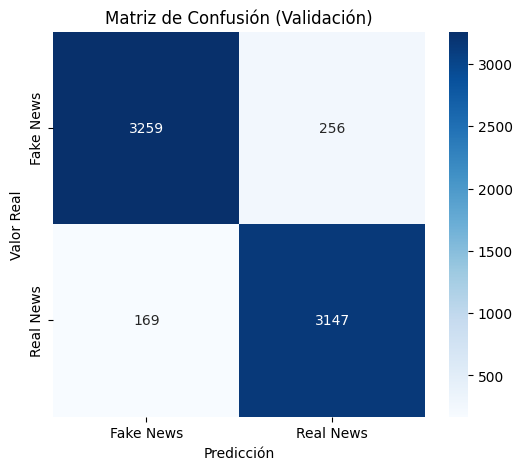

In [9]:
#================
# EVALUAR MODELO
#================

# 1. Poner el modelo en modo evaluación.
model_nn.eval()
all_preds = [] # Lista para almacenar predicciones.
all_true = []  # Lista para almacenar etiquetas reales.

with torch.no_grad(): # Desactivar el cálculo de gradientes.

# 2. Recorrer el conjunto de validación para obtener predicciones.
    for emb, lbl in val_loader_pt:
        emb = emb.to(device)         # Mover embeddings al dispositivo.
        logits = model_nn(emb)          # Obtener los logits del modelo.
        preds_prob = torch.sigmoid(logits) # Convertir logits a probabilidades.
        preds = (preds_prob > 0.5).float().cpu().numpy().flatten() # Convertir probabilidades a clases binarias.
        all_preds.extend(preds)      # Añadir predicciones.
        all_true.extend(lbl.numpy().flatten()) # Añadir etiquetas reales.

# 3. Calcular métricas de rendimiento.
acc = accuracy_score(all_true, all_preds) # Precisión general.
f2 = fbeta_score(all_true, all_preds, beta=2) # F2-Score (prioriza recall).
tn, fp, fn, tp = confusion_matrix(all_true, all_preds).ravel() # Matriz de confusión.

print("\n" + "="*60)
print("EVALUACIÓN FINAL EN VALIDACIÓN")
print("="*60)

# 4. Imprimir los resultados de la evaluación.
print(f"Accuracy: {acc:.4f} ({acc*100:.2f}%)")
print(f"F2-Score (prioriza recall): {f2:.4f}")
print(f"Matriz de confusión:")
print(f"  TN (Fake bien detectado): {tn} (Verdaderos Negativos)")
print(f"  FP (Fake predicho como Real): {fp} (Falsos Positivos)")
print(f"  FN (Real predicho como Fake): {fn} (Falsos Negativos)")
print(f"  TP (Real bien detectado): {tp} (Verdaderos Positivos)")


# 5. Visualización de la Matriz de Confusión.
cm_val = confusion_matrix(all_true, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake News', 'Real News'],
            yticklabels=['Fake News', 'Real News'])
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión (Validación)')
plt.show()

In [10]:
#============================================
# PREDICCIONES CON ARCHIVO "testing_data.csv"
#============================================

# 1. Cargar el dataset de prueba 'testing_data.csv'.
print("Cargando testing_data.csv ...")
df_test = pd.read_csv("testing_data.csv",
                      header=None,
                      sep=None,
                      engine='python',
                      encoding='utf-8')

# 2. Nombrar las columnas 'label' y 'headline'.
df_test.columns = ["label", "headline"]

# 3. Limpiar y convertir tipos de datos en columnas de prueba.
df_test["label"] = df_test["label"].astype(str).str.replace('\ufeff', '', regex=False) # Quitar BOM de 'label'.
df_test["headline"] = df_test["headline"].astype(str).replace(["nan", "NaN", "None", ""], " ") # Manejar nulos en 'headline'.
df_test["label"] = pd.to_numeric(df_test["label"], errors='coerce') # Convertir 'label' a numérico.

print(f"\nFilas en test: {len(df_test)}")
print("Primeras 5 filas de test:")
print(df_test.head())

# 4. Aplicar el preprocesamiento de texto a los titulares de prueba.
df_test['clean_headline'] = df_test['headline'].apply(clean_headline)

# 5. Crear un Dataset y DataLoader para los datos de prueba.
test_dataset = FakeNewsDataset(df_test, text_column='clean_headline')
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 6. Generar embeddings para el conjunto de prueba.
print("\nGenerando embeddings para TEST...")
test_embeddings, _ = get_embeddings(test_loader, tokenizer, model, device)

print(f"\nEmbeddings de test generados: {test_embeddings.shape}")

print("\n" + "="*80)
print("PREDICIENDO CON EL MODELO")
print("="*80)

# 7. Realizar predicciones con el modelo entrenado.
model_nn.eval() # Poner el modelo en modo evaluación.

with torch.no_grad(): # Desactivar el cálculo de gradientes.
    test_tensor = torch.tensor(test_embeddings, dtype=torch.float32).to(device) # Convertir embeddings a tensor.
    logits = model_nn(test_tensor) # Obtener los logits de predicción.
    preds_prob = torch.sigmoid(logits).cpu().numpy().flatten() # Convertir logits a probabilidades y luego a NumPy.
    preds = (preds_prob > 0.5).astype(int) # Convertir probabilidades a clases binarias.

print("\nPredicciones generadas. Primeras 10 probabilidades y clases:")
for i in range(min(10, len(preds_prob))):
    print(f"Prob: {preds_prob[i]:.4f} → Clase: {preds[i]}")

# 8. Crear un DataFrame con las predicciones y los titulares originales.
df_output = pd.DataFrame({
    "label": preds,
    "headline": df_test["headline"]
})

# 9. Guardar las predicciones en un archivo CSV.
df_output.to_csv("predictions.csv", index=False, header=False, sep=",")

print("\n" + "="*80)
print("ARCHIVO GENERADO")
print("="*80)
print("Archivo guardado como: predictions.csv")
print(f"Número de predicciones: {len(df_output)}")
print("Primeras 5 líneas del CSV final:")
print(df_output.head())

print("\n¡CSV Nuevo predictions.csv generado en la misma carpeta del proyecto.")
print("Estimación de rendimiento: ~93-94% accuracy basada en validación.")

Cargando testing_data.csv ...

Filas en test: 9984
Primeras 5 filas de test:
   label                                           headline
0      2  copycat muslim terrorist arrested with assault...
1      2  wow! chicago protester caught on camera admits...
2      2   germany's fdp look to fill schaeuble's big shoes
3      2  mi school sends welcome back packet warning ki...
4      2  u.n. seeks 'massive' aid boost amid rohingya '...

Generando embeddings para TEST...


/tmp/ipython-input-1334283571.py:41: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  all_labels.append(torch.tensor(batch_labels).numpy()) # Guardar etiquetas.


Procesando batch de 64 textos...
Embeddings generados.

Embeddings de test generados: (9984, 768)

PREDICIENDO CON EL MODELO

Predicciones generadas. Primeras 10 probabilidades y clases:
Prob: 0.0281 → Clase: 0
Prob: 0.0000 → Clase: 0
Prob: 0.9917 → Clase: 1
Prob: 0.0530 → Clase: 0
Prob: 0.9999 → Clase: 1
Prob: 0.0000 → Clase: 0
Prob: 0.9967 → Clase: 1
Prob: 0.2249 → Clase: 0
Prob: 0.9999 → Clase: 1
Prob: 0.9842 → Clase: 1

ARCHIVO GENERADO
Archivo guardado como: predictions.csv
Número de predicciones: 9984
Primeras 5 líneas del CSV final:
   label                                           headline
0      0  copycat muslim terrorist arrested with assault...
1      0  wow! chicago protester caught on camera admits...
2      1   germany's fdp look to fill schaeuble's big shoes
3      0  mi school sends welcome back packet warning ki...
4      1  u.n. seeks 'massive' aid boost amid rohingya '...

¡CSV Nuevo predictions.csv generado en la misma carpeta del proyecto.
Estimación de rendimien

In [17]:
#=============================
# PROBAR CON NUEVOS TITULARES
#=============================

# 1. Definir un nuevo mensaje de prueba.
nuevo_titular = "Add New Headline Here"

# 2. Generar el embedding del nuevo Titular con DistilBERT.
inputs = tokenizer(
    nuevo_titular,
    return_tensors="pt", # Devolver tensores de PyTorch.
    padding=True,
    truncation=True,
    max_length=128
)
inputs = {k: v.to(device) for k, v in inputs.items()} # Mover inputs al dispositivo.

model.eval() # Poner el modelo DistilBERT en modo evaluación.
with torch.no_grad():
    outputs = model(**inputs)

cls_embedding = outputs.last_hidden_state[:, 0, :] # Extraer el embedding del token [CLS].
nuevo_embedding_tensor = cls_embedding.cpu().to(device) # Mover al dispositivo del clasificador.

# 3. Predecir con nuestro modelo clasificador FakeNewsClassifier.
model_nn.eval() # Poner el clasificador en modo evaluación.
with torch.no_grad(): # Desactivar el cálculo de gradientes.
    logits = model_nn(nuevo_embedding_tensor) # Obtener los logits del clasificador.
    prediccion_prob = torch.sigmoid(logits).item() # Convertir logits a probabilidad como un escalar.

# 4. Determinar la clase predicha (FAKE NEWS o REAL NEWS).
if prediccion_prob > 0.5:
    prediccion_clase = "REAL NEWS"
else:
    prediccion_clase = "FAKE NEWS"

# 5. Imprimir los resultados.
print(f"Titular: '{nuevo_titular}'")
print(f"Probabilidad de Noticia Real: {prediccion_prob:.2%}")
print(f"Clasificación: {prediccion_clase}")

Titular: 'Julio Iglesias sexual assault complaint dropped in Spain'
Probabilidad de Noticia Real: 99.43%
Clasificación: REAL NEWS
